In [ ]:
import random
import gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import os
from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display


GPU = True
device_idx = 0
if GPU:
    device = torch.device("cuda:" + str(device_idx) if torch.cuda.is_available() else "cpu")
else:
    device = torch.device("cpu")
print(device)

cpu


In [2]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0
    
    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = int((self.position + 1) % self.capacity)  # as a ring buffer
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch)) # stack for each element
        ''' 
        the * serves as unpack: sum(a,b) <=> batch=(a,b), sum(*batch) ;
        zip: a=[1,2], b=[2,3], zip(a,b) => [(1, 2), (2, 3)] ;
        the map serves as mapping the function on each list element: map(square, [2,3]) => [4,9] ;
        np.stack((1,2)) => array([1, 2])
        '''
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

In [3]:
class NormalizedActions(gymnasium.ActionWrapper):
    def action(self, action):
        low  = self.action_space.low
        high = self.action_space.high
        
        action = low + (action + 1.0) * 0.5 * (high - low)
        action = np.clip(action, low, high)
        
        return action

    def reverse_action(self, action):
        low  = self.action_space.low
        high = self.action_space.high
        
        action = 2 * (action - low) / (high - low) - 1
        action = np.clip(action, low, high)
        
        return action


class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim, init_w=3e-3):
        super(ValueNetwork, self).__init__()
        
        self.linear1 = nn.Linear(state_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, hidden_dim)
        self.linear4 = nn.Linear(hidden_dim, 1)
        # weights initialization
        self.linear4.weight.data.uniform_(-init_w, init_w)
        self.linear4.bias.data.uniform_(-init_w, init_w)
        
    def forward(self, state):
        x = F.relu(self.linear1(state))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = self.linear4(x)
        return x

In [4]:
class SoftQNetwork(nn.Module):
    def __init__(self, num_inputs, num_actions, hidden_size, init_w=3e-3):
        super(SoftQNetwork, self).__init__()
        
        self.linear1 = nn.Linear(num_inputs + num_actions, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, 1)
        
        self.linear4.weight.data.uniform_(-init_w, init_w)
        self.linear4.bias.data.uniform_(-init_w, init_w)
        
    def forward(self, state, action):
        x = torch.cat([state, action], 1) # the dim 0 is number of samples
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = self.linear4(x)
        return x
        
        
class PolicyNetwork(nn.Module):
    def __init__(self, num_inputs, num_actions, hidden_size, action_range=1., init_w=3e-3, log_std_min=-20, log_std_max=2):
        super(PolicyNetwork, self).__init__()
        
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max
        
        self.linear1 = nn.Linear(num_inputs, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)

        self.mean_linear = nn.Linear(hidden_size, num_actions)
        self.mean_linear.weight.data.uniform_(-init_w, init_w)
        self.mean_linear.bias.data.uniform_(-init_w, init_w)
        
        self.log_std_linear = nn.Linear(hidden_size, num_actions)
        self.log_std_linear.weight.data.uniform_(-init_w, init_w)
        self.log_std_linear.bias.data.uniform_(-init_w, init_w)

        self.action_range = action_range
        self.num_actions = num_actions

        
    def forward(self, state):
        x = F.relu(self.linear1(state))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = F.relu(self.linear4(x))

        mean    = (self.mean_linear(x))
        # mean    = F.leaky_relu(self.mean_linear(x))
        log_std = self.log_std_linear(x)
        log_std = torch.clamp(log_std, self.log_std_min, self.log_std_max)
        
        return mean, log_std
    
    def evaluate(self, state, epsilon=1e-6):
        '''
        generate sampled action with state as input wrt the policy network;
        '''
        mean, log_std = self.forward(state)
        std = log_std.exp() # no clip in evaluation, clip affects gradients flow
        
        normal = Normal(0, 1)
        z      = normal.sample(mean.shape) 
        action_0 = torch.tanh(mean + std*z.to(device)) # TanhNormal distribution as actions; reparameterization trick
        action = self.action_range*action_0
        # The log-likelihood here is for the TanhNorm distribution instead of only Gaussian distribution. \
        # The TanhNorm forces the Gaussian with infinite action range to be finite. \
        # For the three terms in this log-likelihood estimation: \
        # (1). the first term is the log probability of action as in common \
        # stochastic Gaussian action policy (without Tanh); \
        # (2). the second term is the caused by the Tanh(), \
        # as shown in appendix C. Enforcing Action Bounds of https://arxiv.org/pdf/1801.01290.pdf, \
        # the epsilon is for preventing the negative cases in log; \
        # (3). the third term is caused by the action range I used in this code is not (-1, 1) but with \
        # an arbitrary action range, which is slightly different from original paper.
        log_prob = Normal(mean, std).log_prob(mean+ std*z.to(device)) - torch.log(1. - action_0.pow(2) + epsilon) -  np.log(self.action_range)
        # both dims of normal.log_prob and -log(1-a**2) are (N,dim_of_action); 
        # the Normal.log_prob outputs the same dim of input features instead of 1 dim probability, 
        # needs sum up across the features dim to get 1 dim prob; or else use Multivariate Normal.
        log_prob = log_prob.sum(dim=1, keepdim=True)
        return action, log_prob, z, mean, log_std
        
    
    def get_action(self, state, deterministic):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        mean, log_std = self.forward(state)
        std = log_std.exp()
        
        normal = Normal(0, 1)
        z      = normal.sample(mean.shape).to(device)
        action = self.action_range* torch.tanh(mean + std*z)
        
        action = self.action_range* torch.tanh(mean).detach().cpu().numpy()[0] if deterministic else action.detach().cpu().numpy()[0]
        return action


    def sample_action(self,):
        a=torch.FloatTensor(self.num_actions).uniform_(-1, 1)
        return self.action_range*a.numpy()

In [5]:
class SAC_Trainer():
    def __init__(self, replay_buffer, hidden_dim, action_range):
        self.replay_buffer = replay_buffer

        self.soft_q_net1 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.soft_q_net2 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_soft_q_net1 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_soft_q_net2 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.policy_net = PolicyNetwork(state_dim, action_dim, hidden_dim, action_range).to(device)
        self.log_alpha = torch.zeros(1, dtype=torch.float32, requires_grad=True, device=device)
        print('Soft Q Network (1,2): ', self.soft_q_net1)
        print('Policy Network: ', self.policy_net)

        for target_param, param in zip(self.target_soft_q_net1.parameters(), self.soft_q_net1.parameters()):
            target_param.data.copy_(param.data)
        for target_param, param in zip(self.target_soft_q_net2.parameters(), self.soft_q_net2.parameters()):
            target_param.data.copy_(param.data)

        self.soft_q_criterion1 = nn.MSELoss()
        self.soft_q_criterion2 = nn.MSELoss()

        soft_q_lr = 3e-4
        policy_lr = 3e-4
        alpha_lr  = 3e-4

        self.soft_q_optimizer1 = optim.Adam(self.soft_q_net1.parameters(), lr=soft_q_lr)
        self.soft_q_optimizer2 = optim.Adam(self.soft_q_net2.parameters(), lr=soft_q_lr)
        self.policy_optimizer = optim.Adam(self.policy_net.parameters(), lr=policy_lr)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=alpha_lr)

    
    def update(self, batch_size, reward_scale=10., auto_entropy=True, target_entropy=-2, gamma=0.99,soft_tau=1e-2):
        state, action, reward, next_state, done = self.replay_buffer.sample(batch_size)
        # print('sample:', state, action,  reward, done)

        state      = torch.FloatTensor(state).to(device)
        next_state = torch.FloatTensor(next_state).to(device)
        action     = torch.FloatTensor(action).to(device)
        reward     = torch.FloatTensor(reward).unsqueeze(1).to(device)  # reward is single value, unsqueeze() to add one dim to be [reward] at the sample dim;
        done       = torch.FloatTensor(np.float32(done)).unsqueeze(1).to(device)

        predicted_q_value1 = self.soft_q_net1(state, action)
        predicted_q_value2 = self.soft_q_net2(state, action)
        new_action, log_prob, z, mean, log_std = self.policy_net.evaluate(state)
        new_next_action, next_log_prob, _, _, _ = self.policy_net.evaluate(next_state)
        reward = reward_scale * (reward - reward.mean(dim=0)) / (reward.std(dim=0) + 1e-6) # normalize with batch mean and std; plus a small number to prevent numerical problem
    # Updating alpha wrt entropy
        # alpha = 0.0  # trade-off between exploration (max entropy) and exploitation (max Q) 
        if auto_entropy is True:
            alpha_loss = -(self.log_alpha * (log_prob + target_entropy).detach()).mean()
            # print('alpha loss: ',alpha_loss)
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp()
        else:
            self.alpha = 1.
            alpha_loss = 0

    # Training Q Function
        target_q_min = torch.min(self.target_soft_q_net1(next_state, new_next_action),self.target_soft_q_net2(next_state, new_next_action)) - self.alpha * next_log_prob
        target_q_value = reward + (1 - done) * gamma * target_q_min # if done==1, only reward
        q_value_loss1 = self.soft_q_criterion1(predicted_q_value1, target_q_value.detach())  # detach: no gradients for the variable
        q_value_loss2 = self.soft_q_criterion2(predicted_q_value2, target_q_value.detach())


        self.soft_q_optimizer1.zero_grad()
        q_value_loss1.backward()
        self.soft_q_optimizer1.step()
        self.soft_q_optimizer2.zero_grad()
        q_value_loss2.backward()
        self.soft_q_optimizer2.step()  

    # Training Policy Function
        predicted_new_q_value = torch.min(self.soft_q_net1(state, new_action),self.soft_q_net2(state, new_action))
        policy_loss = (self.alpha * log_prob - predicted_new_q_value).mean()

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()
        
        # print('q loss: ', q_value_loss1, q_value_loss2)
        # print('policy loss: ', policy_loss )


    # Soft update the target value net
        for target_param, param in zip(self.target_soft_q_net1.parameters(), self.soft_q_net1.parameters()):
            target_param.data.copy_(  # copy data value into target parameters
                target_param.data * (1.0 - soft_tau) + param.data * soft_tau
            )
        for target_param, param in zip(self.target_soft_q_net2.parameters(), self.soft_q_net2.parameters()):
            target_param.data.copy_(  # copy data value into target parameters
                target_param.data * (1.0 - soft_tau) + param.data * soft_tau
            )
        return predicted_new_q_value.mean()

    def save_model(self, path):
        # Ensure directory exists
        os.makedirs(os.path.dirname(path), exist_ok=True)

        torch.save(self.soft_q_net1.state_dict(), path+'_q1')
        torch.save(self.soft_q_net2.state_dict(), path+'_q2')
        torch.save(self.policy_net.state_dict(), path+'_policy')

    def load_model(self, path):
        self.soft_q_net1.load_state_dict(torch.load(path+'_q1'))
        self.soft_q_net2.load_state_dict(torch.load(path+'_q2'))
        self.policy_net.load_state_dict(torch.load(path+'_policy'))

        self.soft_q_net1.eval()
        self.soft_q_net2.eval()
        self.policy_net.eval()


def plot(rewards):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.plot(rewards)
    plt.savefig('sac_v2.png')
    # plt.show()

In [6]:
replay_buffer_size = 1e6
replay_buffer = ReplayBuffer(replay_buffer_size)

# choose env

env = NormalizedActions(gymnasium.make('Pendulum-v1'))
action_dim = env.action_space.shape[0]
state_dim  = env.observation_space.shape[0]
action_range=1.

# hyper-parameters for RL training
max_episodes  = 100
max_steps = 150  # Pendulum needs 150 steps per episode to learn well
frame_idx   = 0
batch_size  = 300
explore_steps = 0  # for random action sampling in the beginning of training
update_itr = 1
AUTO_ENTROPY=True
DETERMINISTIC=False
hidden_dim = 512
rewards     = []
model_path = 'model_checkpoints/sac_v2'

sac_trainer=SAC_Trainer(replay_buffer, hidden_dim=hidden_dim, action_range=action_range  )


Soft Q Network (1,2):  SoftQNetwork(
  (linear1): Linear(in_features=4, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=512, bias=True)
  (linear3): Linear(in_features=512, out_features=512, bias=True)
  (linear4): Linear(in_features=512, out_features=1, bias=True)
)
Policy Network:  PolicyNetwork(
  (linear1): Linear(in_features=3, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=512, bias=True)
  (linear3): Linear(in_features=512, out_features=512, bias=True)
  (linear4): Linear(in_features=512, out_features=512, bias=True)
  (mean_linear): Linear(in_features=512, out_features=1, bias=True)
  (log_std_linear): Linear(in_features=512, out_features=1, bias=True)
)


Episode:  80 | Episode Reward:  -238.49888226032988
Episode:  81 | Episode Reward:  -121.10572000280146
Episode:  82 | Episode Reward:  -127.0666104429811
Episode:  83 | Episode Reward:  -232.45317153588525
Episode:  84 | Episode Reward:  -4.2928260703714995
Episode:  85 | Episode Reward:  -119.35929946753429
Episode:  86 | Episode Reward:  -238.6176009814637
Episode:  87 | Episode Reward:  -230.18071254918354
Episode:  88 | Episode Reward:  -2.082398901613666
Episode:  89 | Episode Reward:  -129.0505964082061
Episode:  90 | Episode Reward:  -121.26677601465727
Episode:  91 | Episode Reward:  -121.79132275374683
Episode:  92 | Episode Reward:  -122.10235694720129
Episode:  93 | Episode Reward:  -120.81360783766476
Episode:  94 | Episode Reward:  -251.36392241028292
Episode:  95 | Episode Reward:  -128.89846111359427
Episode:  96 | Episode Reward:  -233.4884692808026
Episode:  97 | Episode Reward:  -117.1090799040358
Episode:  98 | Episode Reward:  -122.49411088367147
Episode:  99 | Epi

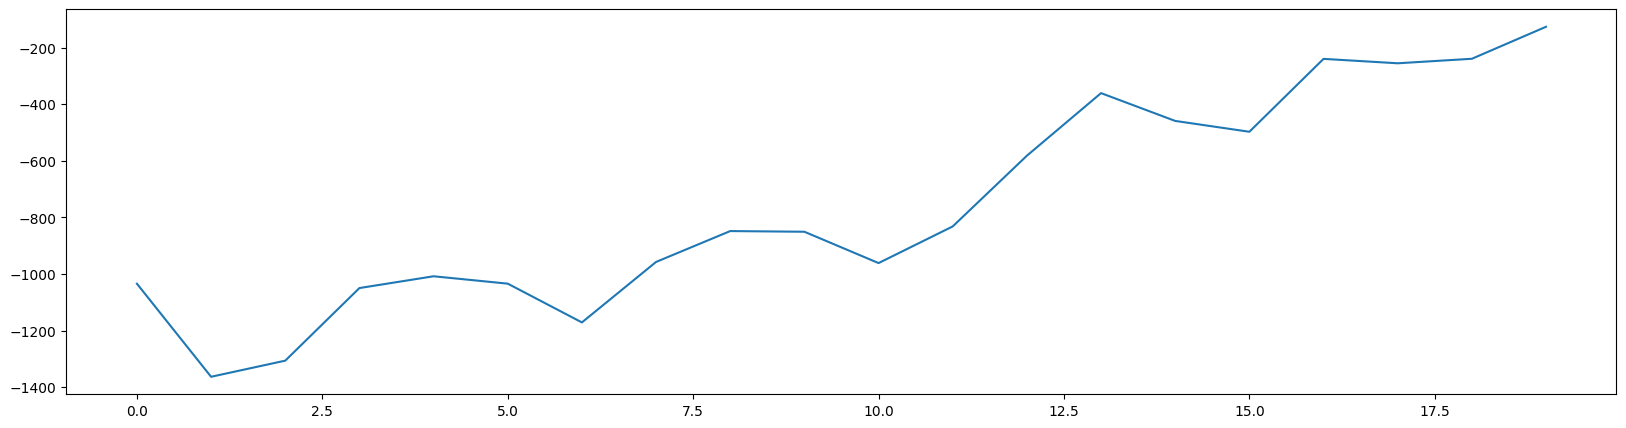

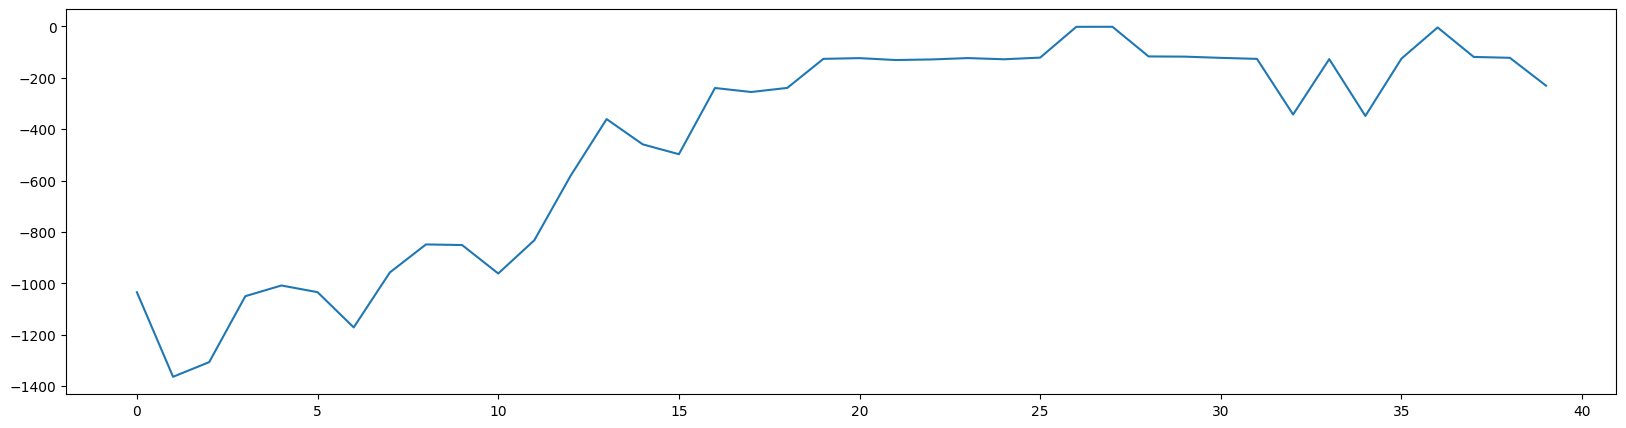

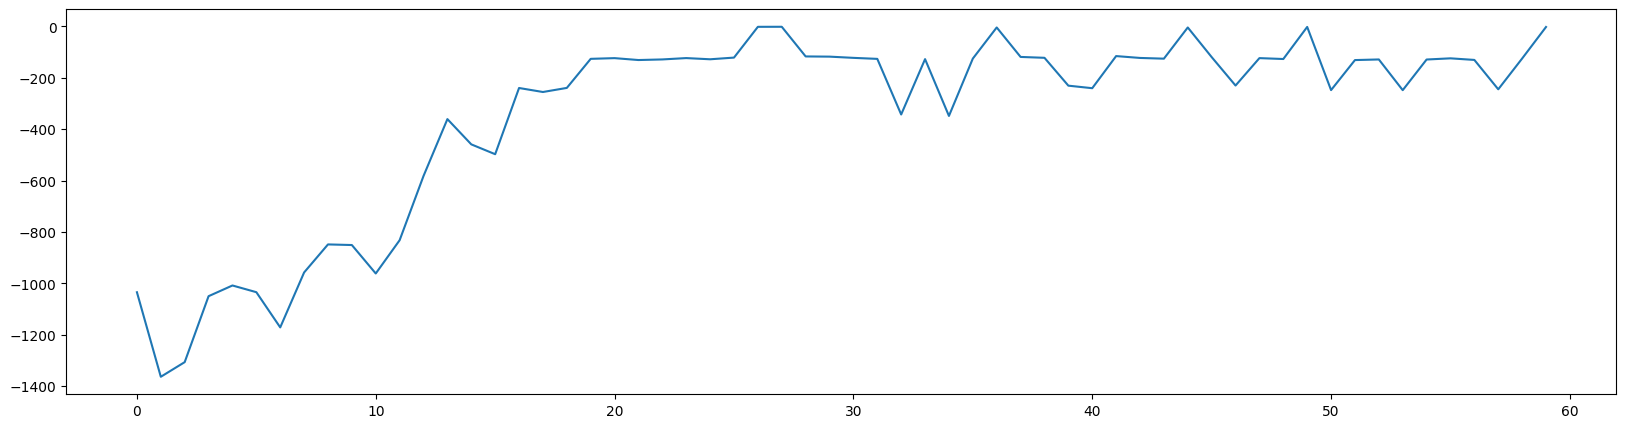

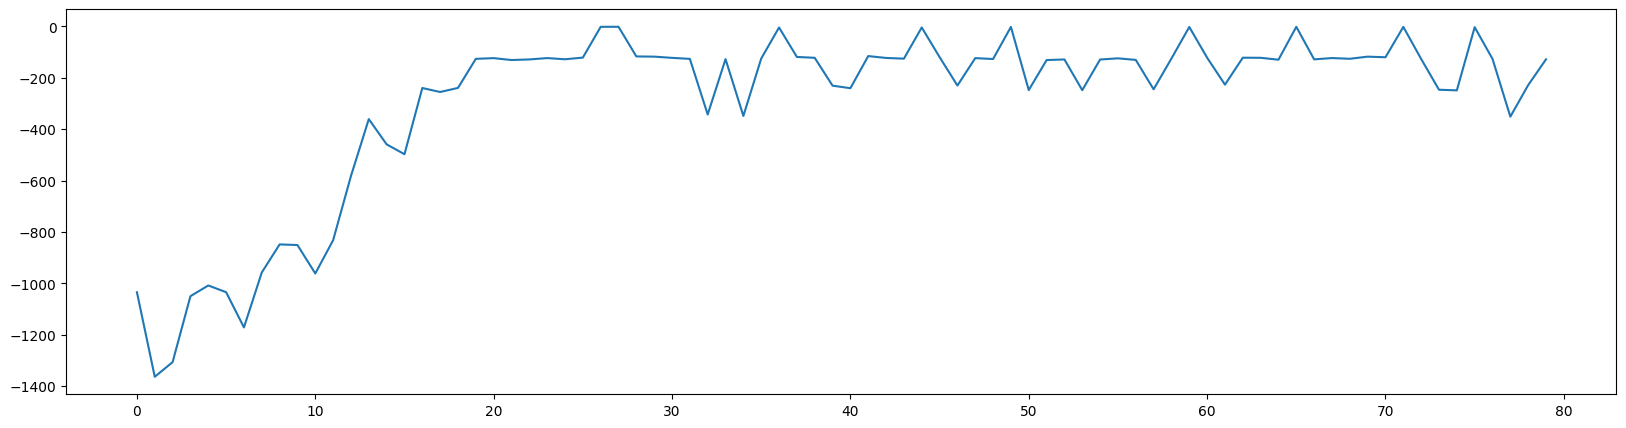

In [7]:
for eps in range(max_episodes):
    state, _ =  env.reset()
    episode_reward = 0
    
    
    for step in range(max_steps):
        if frame_idx > explore_steps:
            action = sac_trainer.policy_net.get_action(state, deterministic = DETERMINISTIC)
        else:
            action = sac_trainer.policy_net.sample_action()
        
        # next_state, reward, done, _ = env.step(action) 
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated         
        replay_buffer.push(state, action, reward, next_state, done)
        
        state = next_state
        episode_reward += reward
        frame_idx += 1
        
        
        if len(replay_buffer) > batch_size:
            for i in range(update_itr):
                _=sac_trainer.update(batch_size, reward_scale=10., auto_entropy=AUTO_ENTROPY, target_entropy=-1.*action_dim)

        if done:
            break

    if eps % 20 == 0 and eps>0: # plot and model saving interval
        plot(rewards)
        np.save('rewards', rewards)
        sac_trainer.save_model(model_path)
    print('Episode: ', eps, '| Episode Reward: ', episode_reward)
    rewards.append(episode_reward)
sac_trainer.save_model(model_path)

In [8]:
sac_trainer.load_model(model_path)
for eps in range(10):
    state, _ =  env.reset()
    episode_reward = 0

    for step in range(max_steps):
        action = sac_trainer.policy_net.get_action(state, deterministic = DETERMINISTIC)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        env.render()   


        episode_reward += reward
        state=next_state

    print('Episode: ', eps, '| Episode Reward: ', episode_reward)

Episode:  0 | Episode Reward:  -254.6245549882576


/Users/debabratamishra/miniconda3/envs/py312/lib/python3.12/site-packages/gymnasium/envs/classic_control/pendulum.py:178: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Pendulum-v1", render_mode="rgb_array")
  gym.logger.warn(


Episode:  1 | Episode Reward:  -237.6400030402802
Episode:  2 | Episode Reward:  -130.8335085305929
Episode:  3 | Episode Reward:  -124.89406696903245
Episode:  4 | Episode Reward:  -128.6711035954503
Episode:  5 | Episode Reward:  -121.37462359117673
Episode:  6 | Episode Reward:  -259.33088578367267
Episode:  7 | Episode Reward:  -127.18085815588627
Episode:  8 | Episode Reward:  -4.494002487329702
Episode:  9 | Episode Reward:  -2.5626774519848134


In [9]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import numpy as np

In [10]:
# Reload model
sac_trainer.load_model(model_path)

# Set environment with render_mode for frame capture
env = gymnasium.make("Pendulum-v1", render_mode="rgb_array")  # crucial for rendering frames
state, _ = env.reset()
episode_reward = 0
frames = []

# Run a single episode (for GIF generation)
for step in range(max_steps):
    frame = env.render()  # Capture rendered RGB frame
    frames.append(frame)

    action = sac_trainer.policy_net.get_action(state, deterministic=True)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state = next_state
    episode_reward += reward
    if done:
        break

env.close()
print(f"Episode Reward: {episode_reward}")

# Create animation
fig = plt.figure(figsize=(6, 6))
patch = plt.imshow(frames[0])
plt.axis('off')

def animate(i):
    patch.set_data(frames[i])
    return patch,

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50)

# Prevent showing static plot
plt.close(fig)

# Show only the animation
HTML(ani.to_jshtml())

Episode Reward: -128.08574337579006
